# Deo II - Treniranje i evaluacija modela

## Moduli

In [1]:
import pandas as pd
import ast
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, accuracy_score
import numpy as np

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

## Seed-ovi

In [2]:
RANDOM_STATE = 7

## Pretprocesiranje skupa podataka

In [3]:
data = pd.read_csv('data/protein_data.csv')

In [4]:
data.head()

,accession,sequence,labels
0,P03265,MASREEEQRETTPERGRGAARRPPTMEDVSSPSPSPPPPRAPPKKR...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -..."
1,P49913,MKTQRDGHSLGRWSLVLLLLGLVMPLAIIAQVLSYKEAVLRAIDGI...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -..."
2,P03045,MDAQTRRRERRAEKQAQWKAANPLLVGVSAKPVNRPILSLNRKPKS...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,P00004,MGDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQAPG...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,P27695,MPKRGKKGAVAEDGDELRTEPEAKKSKTAAKKNDKEAAGEGPALYE...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [5]:
data.dtypes

accession    str
sequence     str
labels       str
dtype: object

In [6]:
data['labels'] = data['labels'].apply(ast.literal_eval)
#data.dtypes

Obe neuronske mreže koje treniramo će na početku sadržati `Embedding` sloj. Za to nam je potrebna fiksna dužina sekvence, pa analiziramo šta da postavimo za tu dužinu.

In [7]:
print("Max length: ", data['sequence'].str.len().max())
print("Average length: ", data['sequence'].str.len().mean())

Max length:  34350
Average length:  584.8510638297872


Vidimo da su neki stringovi vrlo dugacki, ali većina je zapravo relativno mala.

In [8]:
data['sequence_length'] = data['sequence'].str.len()
print("Number of proteins having length over 5000: ", data[data['sequence_length'] >= 5000].shape[0])
print("Number of proteins having length over 2000: ", data[data['sequence_length'] >= 2000].shape[0])
print("Number of proteins having length over 1000: ", data[data['sequence_length'] >= 1000].shape[0])
print("Number of proteins having length over 500: ", data[data['sequence_length'] >= 500].shape[0])
data[data['sequence_length'] >= 5000]

Number of proteins having length over 5000:  5
Number of proteins having length over 2000:  109
Number of proteins having length over 1000:  434
Number of proteins having length over 500:  1340


,accession,sequence,labels,sequence_length
52,Q8WZ42,MTTQAPTFTQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQVI...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",34350
1124,O14686,MDSQKLAGEDKDSEPAADGPAASEDPSATESDLPNPHVGEVSVLSS...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -...",5537
1948,P0C6X7,MESLVLGVNEKTHVQLSLPVLQVRDVLVRGFGDSVEEALSEAREHL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",7073
1949,P0DTD1,MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",7096
3305,P11716,MGDGGEGEDEVQFLRTDDEVVLQCSATVLKEQLKLCLAAEGFGNRL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",5037


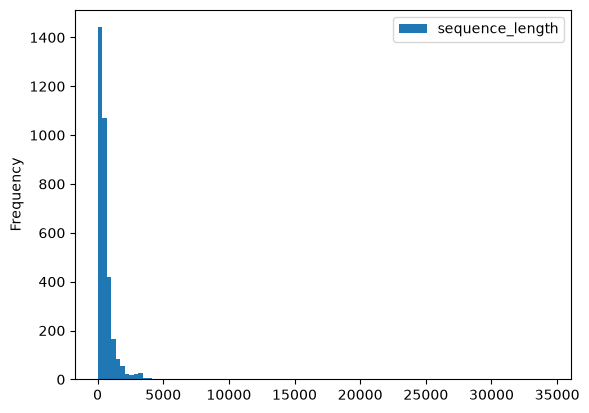

In [9]:
data.plot.hist(bins=100)
plt.show()

Nemamo mnogo proteina dužine veće od $1000$. Nema smisla vršiti padding do maksimalne dužine, pošto će većina instanci imati padding barem $30$ puta duži od njihove prave dužine. Ovaj problem mogli bismo da rešimo izbacivanjem velikih instanci iz skupa podataka, ali mi zaista želimo da smo u mogućnosti da analiziramo i velike proteine. Srećom, struktura naših modela nam omogućava da ovo jednostavno rešimo. Naime, jedan dugačak protein možemo deliti na više manjih, nad kojima model može vršiti predviđanja. Jedini problem koji ovde nastaje je što model gubi na izražajnosti kad su u pitanju dugački proteini, jer se smanjuje kontekst.

In [10]:
MAX_PROTEIN_LENGTH = 1000

RESIDUE_LIST  = list("ACDEFGHIKLMNPQRSTVWY")
VOCAB_SIZE = 22

def get_residue_position(c):
    for j in range(len(RESIDUE_LIST)):
        if c == RESIDUE_LIST[j]:
            # ostavljamo 0 za padding
            return j + 1
    # nestandardne aminokiseline dobijaju zajednicku vrednost
    return len(RESIDUE_LIST) + 1

def tokenize_sequences(sequences):
    result = []
    for sequence in sequences:
        tokenized_seq = []
        for c in sequence:
            tokenized_seq.append(get_residue_position(c.upper()))
        result.append(tokenized_seq)
    return result
    
tokenized_sequences = tokenize_sequences(data['sequence'])
#print(len(tokenized_sequences))
#print(tokenized_sequences[:5])

In [11]:
def split_and_pad(sequence_list, label_list):
    """
    Imamo dva zadatka:
    1) Podeliti predugacke proteine
    2) Pad-ovati prekratke proteine
    """
    
    seq_res = []
    lab_res = []
    
    cnt_new_splits = 0
    
    for i in range(len(sequence_list)):
        sequence = sequence_list[i]
        labels = label_list[i]
        
        # deljenje
        for j in range(len(sequence)):
            l = j*MAX_PROTEIN_LENGTH
            r = j*MAX_PROTEIN_LENGTH + MAX_PROTEIN_LENGTH
            
            if l >= len(sequence):
                break
            
            if j >= 1:
                cnt_new_splits += 1
            
            r = min(r, len(sequence))
            
            seq_split = sequence[l:r]
            lab_split = labels[l:r]
            
            start_len = len(seq_split)
            
            # padding
            for k in range(start_len, MAX_PROTEIN_LENGTH):
                # mozemo kao label dati istu "neutvrdjenu vrednost"
                # svakako to ne racunamo u funkciji greske
                seq_split.append(0)
                lab_split.append(-5)
            
            seq_res.append(seq_split)
            lab_res.append(lab_split)
            
    print("Generated ", cnt_new_splits, " new splits")
    
    return seq_res, lab_res
    
    
seq_train_val, seq_test, labels_train_val, labels_test = train_test_split(tokenized_sequences, data['labels'].tolist(), random_state = RANDOM_STATE, test_size = 0.2)
seq_train, seq_val, labels_train, labels_val = train_test_split(seq_train_val, labels_train_val, random_state = RANDOM_STATE, test_size = 0.2)

seq_train, labels_train = split_and_pad(seq_train, labels_train)
seq_val, labels_val = split_and_pad(seq_val, labels_val)
seq_test, labels_test = split_and_pad(seq_test, labels_test)

seq_train = np.array(seq_train)
labels_train = np.array(labels_train)
seq_val = np.array(seq_val)
labels_val = np.array(labels_val)
seq_test = np.array(seq_test)
labels_test = np.array(labels_test)

Generated  400  new splits
Generated  93  new splits
Generated  146  new splits


In [12]:
BATCH_SIZE = 64

train_loader = DataLoader(list(zip(seq_train, labels_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(list(zip(seq_val, labels_val)), batch_size=BATCH_SIZE)
test_loader = DataLoader(list(zip(seq_test, labels_test)), batch_size=BATCH_SIZE)

## Funkcije

In [13]:
def calculate_metrics(y_target, y_predicted):
    sensitivity = recall_score(y_target, y_predicted)
    specificity = recall_score(y_target, y_predicted, pos_label = 0)
    accuracy = accuracy_score(y_target, y_predicted)
    
    return {'sensitivity' : sensitivity, 'specificity' : specificity, 'accuracy' : accuracy}

In [14]:
from tqdm import tqdm

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, optimizer, n_epochs, train_loader, val_loader, threshold = 0.5):

    metrics = {
        'train_loss': [],
        'train_accuracy': [],
        'train_steps': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_steps': []
    }

    device = get_device()
    
    training_step = 0
    
    best_valid_loss = float('inf')
    eps = 1e-5
    steps_since_improvement = 0
    early_stopping_patience = 10
    
    for epoch in tqdm(range(n_epochs)):

        # Training phase
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            batch_size = labels.size(0)
            labels = labels.to(torch.float32)

            raw_predictions = model(inputs).squeeze()
            probs = torch.sigmoid(raw_predictions) 
            
            mask = (labels > -1)
            
            loss = nn.BCEWithLogitsLoss()(raw_predictions[mask], labels[mask].float())
            accuracy = ((probs[mask] > threshold) == labels[mask]).float().mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            metrics['train_loss'].append(loss.item())
            metrics['train_accuracy'].append(accuracy.item())
            metrics['train_steps'].append(training_step)
            training_step += 1

        # Validation phase
        model.eval()
        valid_loss = 0
        valid_accuracy = 0
        valid_samples = 0
        
        y_target = []
        y_predicted = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                batch_size = labels.size(0)
                labels = labels.to(torch.float32)

                raw_predictions = model(inputs).squeeze()
                probs = torch.sigmoid(raw_predictions)
                
                mask = (labels > -1)
            
                loss = nn.BCEWithLogitsLoss(reduction='sum')(raw_predictions[mask], labels[mask])
                
                correct = ((probs[mask] > threshold) == labels[mask]).float().sum()
                
                y_target.extend((labels[mask]).cpu().numpy())
                y_predicted.extend((probs[mask] > threshold).cpu().numpy())
                
                valid_loss += loss.item()
                valid_accuracy += correct.item()
                valid_samples += mask.sum()
                
        valid_loss /= valid_samples.item()
        valid_accuracy /= valid_samples.item()
        
        adv_metrics = calculate_metrics(y_target, y_predicted)
        
        metrics['val_loss'].append(valid_loss)
        metrics['val_accuracy'].append(adv_metrics['accuracy'])
        metrics['val_steps'].append(training_step)
        
        print('Epoch', epoch, ':', 'Loss', valid_loss, 'Accuracy', adv_metrics['accuracy'], 'Sensitivity', adv_metrics['sensitivity'], 'Specificity', adv_metrics['specificity'])
        
        if best_valid_loss > valid_loss + eps:
            best_valid_loss = valid_loss
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1
            if steps_since_improvement == early_stopping_patience:
                print("\nEARLY STOPPING\n")
                break
        
    
    return metrics

In [15]:
def plot_metrics(metrics):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(metrics['train_steps'], metrics['train_loss'], label='Train Loss')
    plt.plot(metrics['val_steps'], metrics['val_loss'], label='Validation Loss')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(metrics['train_steps'], metrics['train_accuracy'], label='Train Accuracy')
    plt.plot(metrics['val_steps'], metrics['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

## 1D Konvolutivna neuronska mreža

In [16]:
class ConvModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_layers):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        kernel = 5
        channels = 64
        in_channels = embedding_dim
        dropout = 0.3
        
        conv_layers = []
        
        for i in range(n_layers):
            # velika dilatacija kako bismo pokupili sirok kontekst
            dilation = (2 ** i)
            # padding odgovarajuce velicine, kako bismo ocuvali duzinu niza
            pad = dilation * (kernel - 1) // 2
            conv_layers.append(nn.Conv1d(in_channels, channels, kernel_size=kernel, padding = pad, dilation=dilation))
            
            # trebaju nam svi elementi niza, ne mozemo pool-ovati
            conv_layers.append(nn.BatchNorm1d(channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout(dropout))
            
            in_channels = channels
            
        self.full_conv = nn.Sequential(*conv_layers)
        
        self.conv_final = nn.Conv1d(channels, 1, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.full_conv(x)
        x = self.conv_final(x)
        
        return x

In [17]:
device = get_device()

conv_model = ConvModel(vocab_size=VOCAB_SIZE, embedding_dim=32, n_layers = 4)
conv_model.to(device)
optimizer = torch.optim.AdamW(conv_model.parameters(), weight_decay = 1e-4, lr = 1e-3)
conv_metrics = train_model(conv_model, optimizer, 50, train_loader, val_loader, threshold=0.5)

  2%|▊                                          | 1/50 [00:01<01:02,  1.27s/it]

Epoch 0 : Loss 0.6402773071376043 Accuracy 0.6784069939524602 Sensitivity 0.3165816618018261 Specificity 0.9623765927785884


  4%|█▋                                         | 2/50 [00:02<00:51,  1.08s/it]

Epoch 1 : Loss 0.5683550080975486 Accuracy 0.7187528547676905 Sensitivity 0.5178510216165121 Specificity 0.8764256540277019


  6%|██▌                                        | 3/50 [00:03<00:47,  1.01s/it]

...

Epoch 17 : Loss 0.5609923168923455 Accuracy 0.7285001735698756 Sensitivity 0.4876751602281108 Specificity 0.9175056863112756


 38%|███████████████▉                          | 19/50 [00:18<00:29,  1.06it/s]

Epoch 18 : Loss 0.5653633230723467 Accuracy 0.7264036321780278 Sensitivity 0.47236389699695647 Specificity 0.9257803901747063


 38%|███████████████▉                          | 19/50 [00:19<00:31,  1.01s/it]

Epoch 19 : Loss 0.5580529856302413 Accuracy 0.7288062046662891 Sensitivity 0.5031941746564315 Specificity 0.905872186396876

EARLY STOPPING



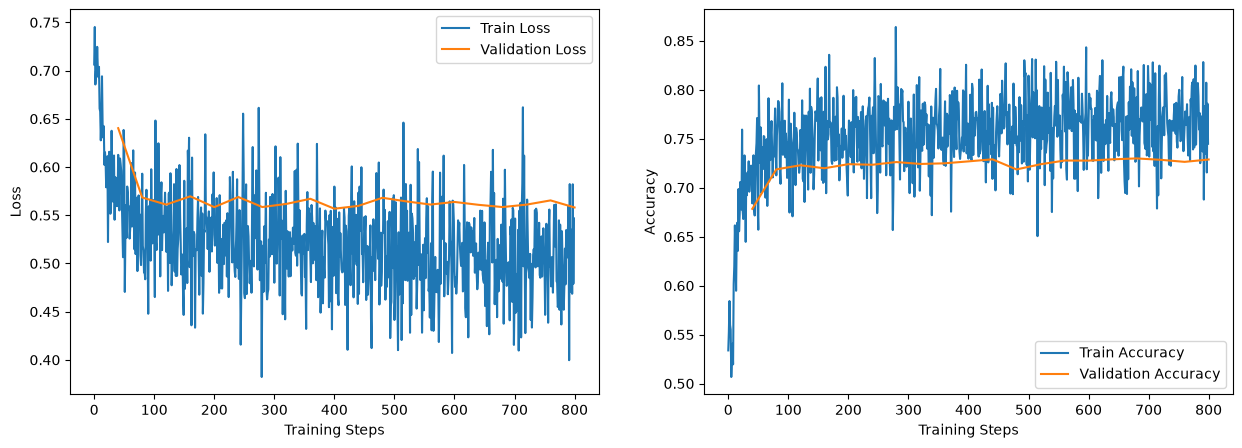

In [18]:
plot_metrics(conv_metrics)

## Rekurentna neuronska mreža - LSTM

In [21]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()

        dropout = 0.2
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # koristimo dvosmerni LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(2*hidden_size, 1)
    
    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)

        #x = self.dropout(x)
        x = self.linear(x)
        return x

In [22]:
device = get_device()

lstm_model = LSTMModel(vocab_size=VOCAB_SIZE, embedding_dim=32, hidden_size=64)
lstm_model.to(device)
optimizer = torch.optim.AdamW(lstm_model.parameters(), weight_decay = 1e-4, lr = 1e-3)
lstm_metrics = train_model(lstm_model, optimizer, 50, train_loader, val_loader, threshold=0.5)

  2%|▊                                          | 1/50 [00:00<00:37,  1.32it/s]

Epoch 0 : Loss 0.6108574228741687 Accuracy 0.6828878373193503 Sensitivity 0.45499589691385595 Specificity 0.8617431499311121


  4%|█▋                                         | 2/50 [00:01<00:35,  1.37it/s]

Epoch 1 : Loss 0.5655798482805163 Accuracy 0.7236676228235251 Sensitivity 0.5163448254370566 Specificity 0.8863797559166171


  6%|██▌                                        | 3/50 [00:02<00:34,  1.38it/s]

...

Epoch 15 : Loss 0.5713468403217095 Accuracy 0.7238457603274076 Sensitivity 0.4926508014002431 Specificity 0.9052933647473158


 34%|██████████████▎                           | 17/50 [00:12<00:23,  1.38it/s]

Epoch 16 : Loss 0.5580543773294905 Accuracy 0.7295872691063892 Sensitivity 0.5114418971839325 Specificity 0.9007932302324254


 34%|██████████████▎                           | 17/50 [00:13<00:25,  1.31it/s]

Epoch 17 : Loss 0.5872010335615054 Accuracy 0.7201779547987502 Sensitivity 0.4302838920109277 Specificity 0.9476940886819987

EARLY STOPPING



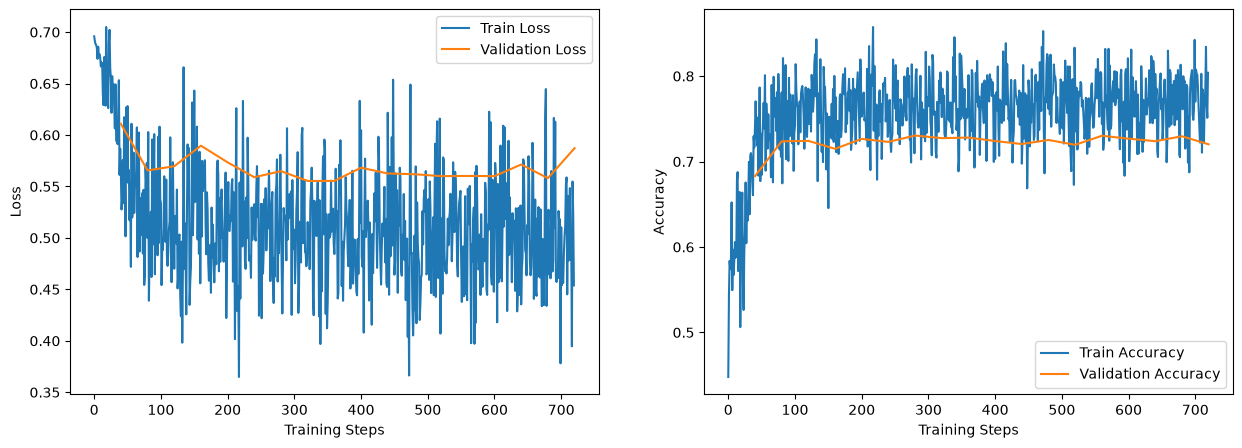

In [23]:
plot_metrics(lstm_metrics)

# Evaluacija

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, evaluation_loader, threshold):
    y = []
    y_predicted = []

    device = get_device()
    
    for inputs, labels in evaluation_loader:
        mask = (labels > -1)
        
        y.extend(labels[mask].squeeze().tolist())

        inputs, labels = inputs.to(device), labels.to(device)
        
        raw_preds = model(inputs).squeeze()
        probs = torch.sigmoid(raw_preds)
        preds = (probs > threshold)
        
        y_predicted.extend(preds[mask].squeeze().tolist())
        
        #probs = torch.sigmoid(raw_predictions)

        #y_predicted.extend((probs[mask] > threshold).cpu().numpy())

    conf = confusion_matrix(y, y_predicted)
    print(conf)
    print(classification_report(y, y_predicted))
    adv_metrics = calculate_metrics(y, y_predicted)

    print('Sensitivity:', adv_metrics['sensitivity'])
    print('Specificity:', adv_metrics['specificity'])
    print('Accuracy:', adv_metrics['accuracy'])

In [25]:
evaluate_model(conv_model, test_loader, threshold = 0.5)

[[138876  21032]
 [ 51878  68349]]
              precision    recall  f1-score   support

           0       0.73      0.87      0.79    159908
           1       0.76      0.57      0.65    120227

    accuracy                           0.74    280135
   macro avg       0.75      0.72      0.72    280135
weighted avg       0.74      0.74      0.73    280135

Sensitivity: 0.5684995882788392
Specificity: 0.8684743727643395
Accuracy: 0.7397326289110607


In [26]:
evaluate_model(lstm_model, test_loader, threshold = 0.3)

[[127921  31987]
 [ 43676  76551]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.77    159908
           1       0.71      0.64      0.67    120227

    accuracy                           0.73    280135
   macro avg       0.73      0.72      0.72    280135
weighted avg       0.73      0.73      0.73    280135

Sensitivity: 0.6367205369842048
Specificity: 0.799966230582585
Accuracy: 0.7299052242668713
